In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
import glob
import geopandas as gpd
import contextily as ctx
import seaborn as sns

In [33]:
def read_plt_file(file_path):
    """
    Reads a PLT file from the GeoLife dataset.
    
    PLT files typically have 6 lines of header followed by data points with:
    latitude, longitude, 0, altitude, date (as days since 12/30/1899), date as string, time as string
    """
    # Skip the header (first 6 lines)
    data = pd.read_csv(
        file_path, 
        skiprows=6,
        header=None, 
        names=['latitude', 'longitude', 'zero', 'altitude', 'date_days', 'date', 'time']
    )
    
    # Convert date and time to datetime
    data['datetime'] = pd.to_datetime(data['date'] + ' ' + data['time'])
    
    return data

In [34]:
def read_plt(plt_file):
    points = pd.read_csv(plt_file, skiprows=6, header=None,
                         parse_dates=[[5, 6]], infer_datetime_format=True)

    # for clarity rename columns
    points.rename(inplace=True, columns={'5_6': 'time', 0: 'lat', 1: 'lon', 3: 'alt'})

    # remove unused columns
    points.drop(inplace=True, columns=[2, 4])

    return points

/tmp/ipykernel_28858/3244280456.py:2: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  points = pd.read_csv(plt_file, skiprows=6, header=None,
/tmp/ipykernel_28858/3244280456.py:2: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  points = pd.read_csv(plt_file, skiprows=6, header=None,
/tmp/ipykernel_28858/3244280456.py:2: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  points = pd.read_csv(plt_file, skiprows=6, header=None,
/tmp/ipykernel_28858/3244280456.py:2: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be remov

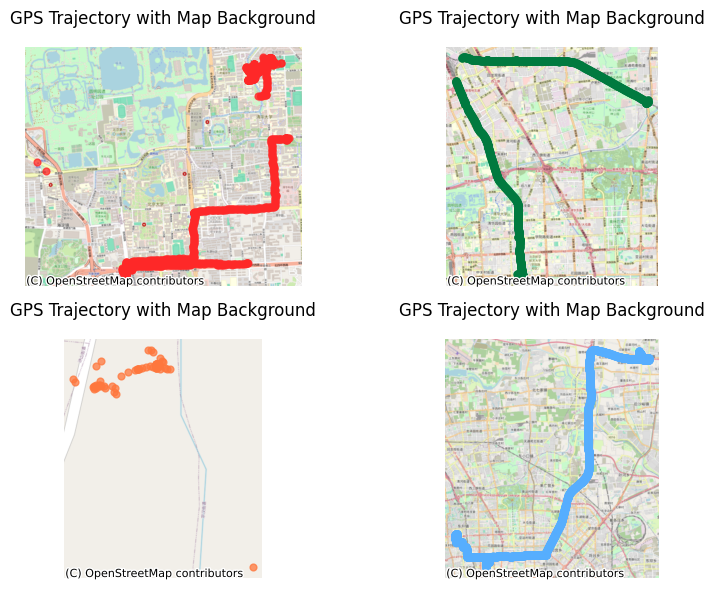

In [50]:
arquivos = ["./geolife/000/Trajectory/20081023025304.plt", "./geolife/168/Trajectory/20090929011428.plt",
            "./geolife/132/Trajectory/20100213212631.plt", "./geolife/014/Trajectory/20081020054500.plt"]
cores = ['#FF2828', '#007A3F', '#FF773D', '#56AEFF']

f, axs = plt.subplots(2, 2, figsize=(12, 6))
axs = axs.flatten()

for i, arq in enumerate(arquivos):
    ax = axs[i]
    dataframe = read_plt(arq)

    gdf = gpd.GeoDataFrame(
        dataframe, geometry=gpd.points_from_xy(dataframe.lon, dataframe.lat), crs="EPSG:4326"
    )
    gdf.head()

    # We need to ensure the CRS is in web mercator for contextily
    gdf_webmerc = gdf.to_crs(epsg=3857)

    # Plot on the map with contextily
    gdf_webmerc.plot(ax=ax, alpha=0.75, color=cores[i], markersize=24)

    # Add the basemap
    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
    # sns.despine(ax=ax)

    ax.set_axis_off()
    ax.set_title("GPS Trajectory with Map Background")
    plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
mode_names = ['walk', 'bike', 'bus', 'car', 'subway','train', 'airplane', 'boat', 'run', 'motorcycle', 'taxi']
mode_ids = {s : i + 1 for i, s in enumerate(mode_names)}

def read_labels(labels_file):
    labels = pd.read_csv(labels_file, skiprows=1, header=None,
                         parse_dates=[[0, 1], [2, 3]],
                         infer_datetime_format=True, delim_whitespace=True)

    # for clarity rename columns
    labels.columns = ['start_time', 'end_time', 'label']

    # replace 'label' column with integer encoding
    labels['label'] = [mode_ids[i] for i in labels['label']]

    return labels

def apply_labels(points, labels):
    indices = labels['start_time'].searchsorted(points['time'], side='right') - 1
    no_label = (indices < 0) | (points['time'].values >= labels['end_time'].iloc[indices].values)
    points['label'] = labels['label'].iloc[indices].values
    points['label'][no_label] = 0

def read_user(user_folder):
    labels = None

    plt_files = glob.glob(os.path.join(user_folder, 'Trajectory', '*.plt'))
    df = pd.concat([read_plt(f) for f in plt_files])

    labels_file = os.path.join(user_folder, 'labels.txt')
    if os.path.exists(labels_file):
        labels = read_labels(labels_file)
        apply_labels(df, labels)
    else:
        df['label'] = 0

    return df

def read_all_users(folder):
    subfolders = os.listdir(folder)
    dfs = []
    for i, sf in enumerate(subfolders):
        print('[%d/%d] processing user %s' % (i + 1, len(subfolders), sf))
        df = read_user(os.path.join(folder,sf))
        df['user'] = int(sf)
        dfs.append(df)
    return pd.concat(dfs)